In [17]:
from utils.utils import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2

base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"

In [18]:
all = [f"NewExp{i}" for i in range(29, 30)]

data_loader = DataLoader(base_path, exp_list=all, to_load=["labels"])

🔄 Loading data for NewExp29...
✅ Loading complete!


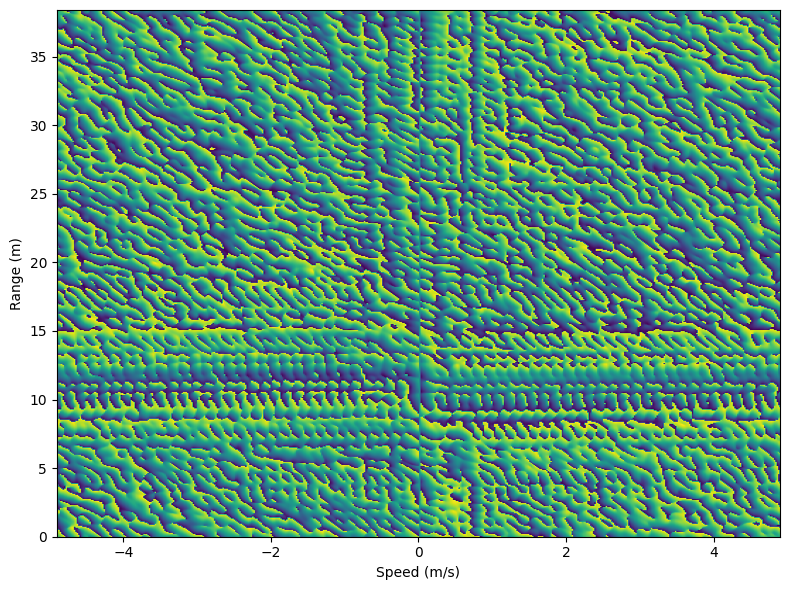

In [32]:
# Load manually the image
folder = "RadarPhasesAntenna1" # "RadarMagnitudesAntenna1" or "RadarPhases"
name = "phase2"
file_path = base_path + "/NewExp29/" + folder + "/map_540_19.png"

img = cv2.imread(file_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

label = data_loader.get_labels()[0]

# Paramètres physiques
v_min, v_max = -4.9, 4.9       # Doppler range in m/s
d_min, d_max = 0.0, 38.4       # Range in meters

# Récupération de la carte d'indices
index = 4

# Définir les valeurs des axes
num_range_bins, num_doppler_bins = img.shape
doppler_axis = np.linspace(v_min, v_max, num_doppler_bins)
range_axis = np.linspace(d_min, d_max, num_range_bins)

# Affichage de la heatmap
plt.figure(figsize=(8, 6))
im = plt.imshow(img, extent=[v_min, v_max, d_min, d_max], aspect='auto', cmap='viridis', origin='lower')

# Titres et étiquettes
#plt.title(f'Radar Doppler Map – Amplitude ({data_loader.get_labels()[index]} people)')
plt.xlabel('Speed (m/s)')
plt.ylabel('Range (m)')

# Barre de couleur
#cbar = plt.colorbar(im)
#cbar.set_label('Magnitude')

# Affichage
plt.tight_layout()
plt.savefig(f"{name}.pdf")
